<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Tutorial 3: Computer Vision with Deep Learning</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Task 3: Advanced CNN Architectures**

Now it's your turn to build and train AlexNet and ResNet by yourself.

In [2]:
## import libraries
from typing import List
import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.python.eager.context import PhysicalDevice

print("TensorFlow version:", tf.__version__)
# setting the growth GPU memory occupying and print devices
try:
    devices: List[PhysicalDevice] = tf.config.list_physical_devices('GPU')
    for device in devices:
        tf.config.experimental.set_memory_growth(device, True)
    print("Use devices:", list(map(lambda d: d.name, devices)))
except IndexError:
    print("Use CPU")

TensorFlow version: 2.21.0
Use devices: []


#### **3.1 Import Data**

In this week, we will use the data from last week. To fit the input size of AlexNet and ResNet, the image is resized to 224 x 224.

Found 3670 images at C:\Repository\CompScience\Computer Science\Intelligent Image and Video Analysis\Module 3 Computer Vision with Deep Learning\Data\flower_photos\flower_photos
Labels: ['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']
The value range of data: (np.float32(0.0), np.float32(0.99971527))
The shape of image: (224, 224, 3)


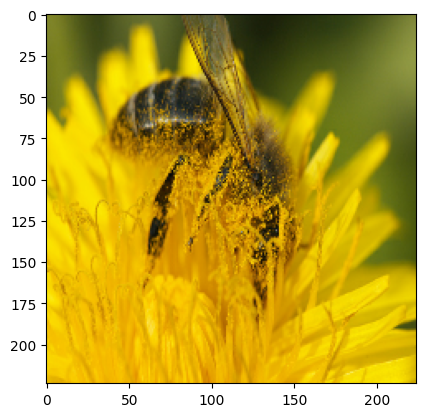

In [3]:
# From Week 6 Lab
from pathlib import Path
from tensorflow.python.data import Dataset, AUTOTUNE

data_dir = Path(r"C:\Repository\CompScience\Computer Science\Intelligent Image and Video Analysis\Module 3 Computer Vision with Deep Learning\Data\flower_photos\flower_photos")

# set the data parameters
batch_size = 32
height = 224
width = 224

# use Python glob instead of TF glob to avoid Windows path issues
all_image_paths = [str(p).replace('\\', '/') for p in data_dir.glob('*/*.jpg')]
image_count = len(all_image_paths)
print(f"Found {image_count} images at {data_dir}")

files_dataset = Dataset.from_tensor_slices(all_image_paths) \
    .shuffle(max(image_count, 1), seed=42, reshuffle_each_iteration=False)

# get all labels
label_names = np.array(sorted([item.name for item in data_dir.glob('*') if item.name != "LICENSE.txt"]))
print("Labels:", label_names)


def get_label(file_path: tf.Tensor) -> tf.Tensor:
    parts = tf.strings.split(tf.expand_dims(file_path, 0), "/").values
    n = tf.shape(parts)[0]
    label_name = parts[n - 2]
    return tf.argmax(label_name == label_names)


def load_image(file_path: tf.Tensor) -> tf.Tensor:
    image_binary = tf.io.read_file(file_path)
    return tf.io.decode_jpeg(image_binary, channels=3)


def resize_image(image: tf.Tensor) -> tf.Tensor:
    return tf.image.resize(image, (height, width))


def normalize_range(image: tf.Tensor) -> tf.Tensor:
    return tf.divide(image, 255)


# define pipeline for loading images
images_dataset = files_dataset.map(load_image, num_parallel_calls=AUTOTUNE) \
    .map(resize_image, num_parallel_calls=AUTOTUNE) \
    .map(normalize_range, num_parallel_calls=AUTOTUNE)

# define pipeline for loading labels
labels_dataset = files_dataset.map(get_label, num_parallel_calls=AUTOTUNE)

# zip images and labels as pairs
pair_dataset = Dataset.zip((images_dataset, labels_dataset))

# split the train and validation dataset
val_size = int(image_count * 0.2)
train_dataset = pair_dataset.skip(val_size)
val_dataset = pair_dataset.take(val_size)

# define the batch_size and shuffle
train_dataset = train_dataset.cache().shuffle(buffer_size=1000).batch(batch_size).prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(AUTOTUNE)

sample_image: tf.Tensor = next(iter(train_dataset))[0][0]
print("The value range of data:", (tf.reduce_min(sample_image).numpy(), tf.reduce_max(sample_image).numpy()))
print("The shape of image:", sample_image.shape)

plt.imshow(sample_image)
plt.show()


#### **3.2 AlexNet**

The architecture of LeNet and AlexNet.

<img src="https://i.imgur.com/WaATiJf.png">

*The figure is from [d2l](https://d2l.ai/chapter_convolutional-modern/alexnet.htmll).*


In [4]:
# TODO - Define AlexNet model.
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

alex_net = Sequential([
    Conv2D(96, 11, strides=4, activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(3, strides=2),
    Conv2D(256, 5, padding="same", activation="relu"),
    MaxPooling2D(3, 2),
    Conv2D(384, 3, padding="same", activation="relu"),
    Conv2D(384, 3, padding="same", activation="relu"),
    Conv2D(256, 3, padding="same", activation="relu"),
    MaxPooling2D(3, strides=2),
    Flatten(),
    Dense(4096, activation="relu"),
    Dropout(0.5),
    Dense(4096, activation="relu"),
    Dropout(0.5),
    Dense(len(label_names))  # we use the length of labels as the dim of output layer.
])

# TODO - Print summary
alex_net.summary()

c:\Repository\CompScience\CompScienceEnv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,767,493 (178.40 MB)

 Trainable params: 46,767,493 (178.40 MB)

 Non-trainable params: 0 (0.00 B)

#### **3.3 ResNet-18**

The residual block used in ResNet.

![](https://i.imgur.com/FyQADBf.png[/img])

*The figure is from [d2l](https://d2l.ai/chapter_convolutional-modern/resnet.html).*

The architecture of ResNet family


![](https://pytorch.org/assets/images/resnet.png)

*The figure is from [He et al., 2016](https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html).*

In [6]:
# TODO - Define ResNet18 model.
from keras.layers import Conv2D, BatchNormalization, ReLU, MaxPooling2D, GlobalAveragePooling2D, Dense, Add, Layer
from keras import Model, Input
from enum import Enum


class ResidualBlockType(Enum):
    SHALLOW = "shallow"
    DEEP = "deep"


class ResidualBlock(Layer):
    class ShallowPath(Layer):
        def __init__(self, filters: int, strides: int):
            super().__init__()
            self.conv0 = Conv2D(filters, kernel_size=3, padding="same", strides=strides)
            self.bn0 = BatchNormalization()
            self.relu0 = ReLU()
            self.conv1 = Conv2D(filters, kernel_size=3, padding="same")
            self.bn1 = BatchNormalization()

        def call(self, inputs, *args, **kwargs):
            x = self.conv0(inputs)
            x = self.bn0(x)
            x = self.relu0(x)
            x = self.conv1(x)
            x = self.bn1(x)
            return x

    class DeepPath(Layer):
        def __init__(self, filters: int, strides: int):
            super().__init__()
            self.conv0 = Conv2D(filters, kernel_size=1, padding="same", strides=strides)
            self.bn0 = BatchNormalization()
            self.relu0 = ReLU()
            self.conv1 = Conv2D(filters, kernel_size=3, padding="same")
            self.bn1 = BatchNormalization()
            self.relu1 = ReLU()
            self.conv2 = Conv2D(filters * 4, kernel_size=1, padding="same")
            self.bn2 = BatchNormalization()

        def call(self, inputs, *args, **kwargs):
            x = self.conv0(inputs)
            x = self.bn0(x)
            x = self.relu0(x)
            x = self.conv1(x)
            x = self.bn1(x)
            x = self.relu1(x)
            x = self.conv2(x)
            x = self.bn2(x)
            return x

    def __init__(self, filters: int, strides: int, repeat: int,
                 architecture: ResidualBlockType = ResidualBlockType.SHALLOW):
        super().__init__()
        if architecture == ResidualBlockType.SHALLOW:
            MainPath = ResidualBlock.ShallowPath
        elif architecture == ResidualBlockType.DEEP:
            MainPath = ResidualBlock.DeepPath
        else:
            raise ValueError("Unknown residual block type")

        self.repeat = repeat
        self.blocks = []
        for i in range(repeat):
            main_path = MainPath(filters, strides=strides) if i == 0 else MainPath(filters, 1)
            residual_path = Conv2D(filters, kernel_size=1, strides=strides) if i == 0 else Layer()
            self.blocks.append((main_path, residual_path, Add(), ReLU()))

    def call(self, inputs, *args, **kwargs):
        x = inputs
        for main_path, residual_path, addition, relu in self.blocks:
            x = relu(addition([main_path(x), residual_path(x)]))
        return x


class ResNet18(Model):

    def __init__(self):
        super().__init__()
        self.conv1 = Conv2D(64, 7, strides=2, padding="same")
        self.bn1 = BatchNormalization()
        self.relu1 = ReLU()
        self.pool1 = MaxPooling2D(3, strides=2, padding="same")

        residual_type = ResidualBlockType.SHALLOW
        self.conv2_x = ResidualBlock(filters=64, strides=1, repeat=2, architecture=residual_type)
        self.conv3_x = ResidualBlock(filters=128, strides=2, repeat=2, architecture=residual_type)
        self.conv4_x = ResidualBlock(filters=256, strides=2, repeat=2, architecture=residual_type)
        self.conv5_x = ResidualBlock(filters=512, strides=2, repeat=2, architecture=residual_type)

        self.global_pool = GlobalAveragePooling2D()
        self.fc = Dense(len(label_names))

        self.build(input_shape=(None, 224, 224, 3))
        self.call(Input(shape=(224, 224, 3)))

    def call(self, inputs, training=None, mask=None):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2_x(x)
        x = self.conv3_x(x)
        x = self.conv4_x(x)
        x = self.conv5_x(x)
        x = self.global_pool(x)
        x = self.fc(x)
        return x

    def get_config(self):
        pass


resnet_18 = ResNet18()


c:\Repository\CompScience\CompScienceEnv\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'res_net18_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Repository\CompScience\CompScienceEnv\Lib\site-packages\keras\src\layers\layer.py:1566: UserWarning: Layer 'residual_block_4' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` met

NotImplementedError: Exception encountered when calling ResidualBlock.call().

[1mCould not automatically infer the output shape / dtype of 'residual_block_4' (of type ResidualBlock). Either the `ResidualBlock.call()` method is incorrect, or you need to implement the `ResidualBlock.compute_output_spec() / compute_output_shape()` method. Error encountered:

Exception encountered when calling Layer.call().

[1mLayer Layer does not have a `call` method implemented.[0m

Arguments received by Layer.call():
  • args=('tf.Tensor(shape=(None, 56, 56, 64), dtype=float32)',)
  • kwargs=<class 'inspect._empty'>[0m

Arguments received by ResidualBlock.call():
  • args=('<KerasTensor shape=(None, 56, 56, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_26>',)
  • kwargs=<class 'inspect._empty'>